# Create the failure dataset at hourly resolution

In [42]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
import data_processing as dp
from zoneinfo import ZoneInfo


from collections import defaultdict

## Load dataset

In [43]:
events_df = dp.load_events()

Loading Events : 2013
Loading Events : 2014
Loading Events : 2015
Loading Events : 2016
Loading Events : 2017
Loading Events : 2018
Loading Events : 2019
Loading Events : 2020
Loading Events : 2021
Loading Events : 2022
Loading Events : 2023
Loading Events : 2024
Loaded 6005103 events


In [44]:
importlib.reload(dp)

filtered_events_df = dp.filter_events(events_df, 
                                      CauseCodes=['U1', 'U2', 'U3', 'D1', 'D2', 'D3', 'SF'], 
                                      filter_fuel=False, 
                                      exclude_states=['Other','Mexico','South America'], 
                                      include_states=None,
                                      add_fuel_failure=False)

Filtering events by cause codes...
Kept 839971 events out of 6005103 (13.99%) after filtering by cause codes.


Adding state and region: 100%|██████████| 834847/834847 [01:11<00:00, 11735.07it/s]


In [45]:
units_start_end = dp.get_units_start_end()

Loading Performances : 2013
Loading Performances : 2014
Loading Performances : 2015
Loading Performances : 2016
Loading Performances : 2017
Loading Performances : 2018
Loading Performances : 2019
Loading Performances : 2020
Loading Performances : 2021
Loading Performances : 2022
Loading Performances : 2023
Loading Performances : 2024
Loaded 1035652 events


100%|██████████| 9305/9305 [00:08<00:00, 1099.41it/s]


In [46]:
import numpy as np
import pandas as pd
from collections import defaultdict
from zoneinfo import ZoneInfo

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

TECH_TARGET = "Gas Turbine/Jet Engine (Simple Cycle Operation)"

# If UnitTimeZone is already an IANA name, ZoneInfo will use it directly.
# Otherwise, these are convenient fallbacks for common utility abbreviations.
TZ_FALLBACK = {
    "EST": "America/New_York",
    "EDT": "America/New_York",
    "EPT": "America/New_York",
    "CST": "America/Chicago",
    "CDT": "America/Chicago",
    "CPT": "America/Chicago",
    "MST": "America/Denver",
    "MDT": "America/Denver",
    "MPT": "America/Denver",
    "PST": "America/Los_Angeles",
    "PDT": "America/Los_Angeles",
    "PPT": "America/Los_Angeles",
    "AKST": "America/Anchorage",
    "AKDT": "America/Anchorage",
    "HST": "Pacific/Honolulu",
    "UTC": "UTC",
}

STATE_PRIORITY = {"A": 0, "D": 1, "U": 2}


def _resolve_timezone(unit_tz_value):
    """
    Return a ZoneInfo object from UnitTimeZone.
    Tries IANA name first, then common fallback abbreviations.
    """
    if pd.isna(unit_tz_value):
        return None
    z = str(unit_tz_value).strip()
    if z == "":
        return None
    try:
        return ZoneInfo(z)
    except Exception:
        mapped = TZ_FALLBACK.get(z)
        if mapped is None:
            return None
        return ZoneInfo(mapped)


def _map_event_type(code):
    """
    Map raw EventTypeCode to {D, U, SF, None}.
    """
    if pd.isna(code):
        return None
    c = str(code).strip().upper()
    if c.startswith("D"):
        return "D"
    if c.startswith("U"):
        return "U"
    if c == "SF":
        return "SF"
    return None


def _clean_events_for_unit(unit_events):
    """
    Input: events for ONE unit, already filtered to one technology, sorted by start time.
    Output: list of simplified intervals dicts with keys:
        start_raw, end_raw, start_hour, end_hour, state
    Rules:
      - D1/2/3 -> D, U1/2/3 -> U
      - SF: if SF.start == previous_event.end, extend previous event end to SF.end; else drop
      - merge overlapping / contiguous intervals of the same simplified state
    """
    simplified = []

    for row in unit_events.itertuples(index=False):
        state = _map_event_type(getattr(row, "EventTypeCode"))
        if state is None:
            continue

        start_raw = pd.Timestamp(getattr(row, "EventStartDT"))
        end_raw = pd.Timestamp(getattr(row, "EventEndDT"))

        if pd.isna(start_raw) or pd.isna(end_raw):
            continue
        if end_raw <= start_raw:
            continue

        # Startup failure handling
        if state == "SF":
            if simplified and start_raw == simplified[-1]["end_raw"]:
                simplified[-1]["end_raw"] = max(simplified[-1]["end_raw"], end_raw)
                simplified[-1]["end_hour"] = simplified[-1]["end_raw"].ceil("h")
            # else drop it
            continue

        event = {
            "start_raw": start_raw,
            "end_raw": end_raw,
            "start_hour": start_raw.floor("h"),
            "end_hour": end_raw.ceil("h"),
            "state": state,
        }

        # Skip zero-hour discretized intervals
        if event["end_hour"] <= event["start_hour"]:
            continue

        if not simplified:
            simplified.append(event)
            continue

        prev = simplified[-1]

        # Merge only if same simplified state and overlapping/contiguous
        if event["state"] == prev["state"] and event["start_hour"] <= prev["end_hour"]:
            prev["end_raw"] = max(prev["end_raw"], event["end_raw"])
            prev["end_hour"] = max(prev["end_hour"], event["end_hour"])
        else:
            simplified.append(event)

    return simplified


def _build_hourly_state_path_for_unit(unit_events, units_start_end):
    """
    Build hourly states for one unit.

    Returns a DataFrame with columns:
      Datetime_local, Initial_gen_state, Final_gen_state, hours_in_state,
      Geographical State, Technology, Datetime_UTC
    or None if it cannot be built.
    """
    # metadata
    unit_id = unit_events["UnitID"].iloc[0]
    geo_state = unit_events["State"].iloc[0]
    technology = unit_events["UnitTypeCodeName"].iloc[0]
    unit_tz_value = unit_events["UnitTimeZone"].iloc[0]
    tz = _resolve_timezone(unit_tz_value)

    if tz is None:
        print(f"⚠️ Unknown timezone for UnitID={unit_id}, UnitTimeZone={unit_tz_value}. Skipping.")
        return None

    # operation window
    op_row = units_start_end.loc[units_start_end["UnitID"] == unit_id]
    if op_row.empty:
        print(f"⚠️ No operation window for UnitID={unit_id}. Skipping.")
        return None

    op_start = pd.Timestamp(op_row["First_Operation_Date"].iloc[0])
    op_end = pd.Timestamp(op_row["Last_Operation_Date"].iloc[0])

    if pd.isna(op_start) or pd.isna(op_end) or op_end <= op_start:
        return None

    # Build hourly grid in local time.
    # We use floor/ceil so events and timeline live on the same hourly lattice.
    t0 = op_start.floor("h")
    t1 = op_end.ceil("h")

    hour_starts = pd.date_range(start=t0, end=t1, freq="h")
    if len(hour_starts) < 2:
        return None

    # Default state: available
    state = np.full(len(hour_starts), "A", dtype=object)
    priority = np.full(len(hour_starts), STATE_PRIORITY["A"], dtype=int)

    # Clean and simplify events for this unit
    cleaned = _clean_events_for_unit(unit_events.sort_values("EventStartDT"))

    # Paint event states onto the hourly grid
    for ev in cleaned:
        mask = (hour_starts >= ev["start_hour"]) & (hour_starts < ev["end_hour"])
        ev_prio = STATE_PRIORITY[ev["state"]]

        # U dominates D if overlapping
        overwrite = mask & (ev_prio >= priority)
        state[overwrite] = ev["state"]
        priority[overwrite] = ev_prio

    # Compute hours_in_state AT EACH HOURLY TIMESTAMP for the current state
    dwell = np.ones(len(hour_starts), dtype=int)
    for i in range(1, len(hour_starts)):
        if state[i] == state[i - 1]:
            dwell[i] = dwell[i - 1] + 1
        else:
            dwell[i] = 1

    # Build transitions:
    # row at time t = transition from S_{t-1} to S_t,
    # with Datetime_local = t and hours_in_state = dwell in the FINAL state S_t
    transitions = pd.DataFrame({
        "Datetime_local": hour_starts[:-1],
        "Geographical State": geo_state,
        "Initial_gen_state": state[:-1],
        "Final_gen_state": state[1:],
        "Technology": technology,
        "hours_in_state": dwell[:-1],
    })

    # Local -> UTC
    dt_local = pd.to_datetime(transitions["Datetime_local"])

    # Try infer first; if DST ambiguity fails, fall back to a deterministic choice
    try:
        dt_utc = (
            dt_local
            .dt.tz_localize(tz, ambiguous="infer", nonexistent="shift_forward")
            .dt.tz_convert("UTC")
        )
    except Exception:
        dt_utc = (
            dt_local
            .dt.tz_localize(tz, ambiguous=False, nonexistent="shift_forward")
            .dt.tz_convert("UTC")
        )

    transitions["Datetime_UTC"] = dt_utc

    return transitions


def build_hourly_transition_dataset(filtered_events_df, units_start_end, tech_target=TECH_TARGET, discretized_log_H=True):
    """
    Main function.

    Returns:
      compressed_df  : compressed hourly transition dataset with Data_weight
    """
    # Filter technology first
    df = filtered_events_df.loc[
        filtered_events_df["UnitTypeCodeName"] == tech_target
    ].copy()

    # Parse datetimes once
    df["EventStartDT"] = pd.to_datetime(df["EventStartDT"], errors="coerce")
    df["EventEndDT"] = pd.to_datetime(df["EventEndDT"], errors="coerce")

    all_rows = []

    for unit_id, unit_events in df.groupby("UnitID"):
        unit_events = unit_events.sort_values("EventStartDT").copy()
        out = _build_hourly_state_path_for_unit(unit_events, units_start_end)
        if out is not None and not out.empty:
            all_rows.append(out)

    if not all_rows:
        empty = pd.DataFrame(columns=[
            "Datetime_UTC", "Geographical State", "Initial_gen_state",
            "Final_gen_state", "Technology", "hours_in_state",
            "Datetime_local", "Data_weight"
        ])
        return empty, empty.copy()

    raw_rows_df = pd.concat(all_rows, ignore_index=True)

    # Log-transform hours_in_state and discretized if requested
    raw_rows_df["hours_in_state"] = np.log10(raw_rows_df["hours_in_state"])
    if discretized_log_H:
        h = raw_rows_df["hours_in_state"].values
        h = np.floor(h*10)/10
        raw_rows_df["hours_in_state"] = h

    # Compress duplicates and create Data_weight
    group_cols = [
        "Datetime_UTC",
        "Geographical State",
        "Initial_gen_state",
        "Final_gen_state",
        "Technology",
        "hours_in_state",
        "Datetime_local",
    ]

    compressed_df = (
        raw_rows_df
        .groupby(group_cols, dropna=False, as_index=False)
        .size()
        .rename(columns={"size": "Data_weight"})
        .sort_values(["Datetime_UTC", "Geographical State"])
        .reset_index(drop=True)
    )

    return compressed_df

In [19]:
compressed_df = build_hourly_transition_dataset(filtered_events_df, units_start_end, discretized_log_H=False)


⚠️ Unknown timezone for UnitID=5415, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5416, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5417, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5418, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5420, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5792, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5793, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5794, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5795, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5796, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5797, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5798, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5799, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=9738, UnitTimeZone=HAST. Skipping.
⚠️ Unknown timezone for UnitID=9745, UnitTimeZone=HAST. Skipping.
⚠️ Unknown

In [21]:
tech_print = TECH_TARGET.replace(" ", "_").replace("/", "_")

compressed_df.to_csv(f"../Data/hourly/by_technology/hourly_failure_deltaTime_dataset_fullH_{tech_print}.csv")

## Initial conditions

In [47]:
def build_initial_conditions_dataset(filtered_events_df, units_start_end, target_date, tech_target=TECH_TARGET):
    """
    Main function.

    Returns:
      initial_df  : initial conditions dataset with one row per hour per unit, and columns:
        Datetime_UTC, UnitID, Initial_gen_state, hours_in_state
    """
    # Filter technology first
    df = filtered_events_df.loc[
        filtered_events_df["UnitTypeCodeName"] == tech_target
    ].copy()

    # Parse datetimes once
    df["EventStartDT"] = pd.to_datetime(df["EventStartDT"], errors="coerce")
    df["EventEndDT"] = pd.to_datetime(df["EventEndDT"], errors="coerce")

    all_rows = []

    for unit_id, unit_events in tqdm(df.groupby("UnitID"), desc="Building initial conditions"):
        unit_events = unit_events.sort_values("EventStartDT").copy()
        out = _build_hourly_state_path_for_unit(unit_events, units_start_end)
        if out is not None and not out.empty:
            out["Datetime_UTC"] = pd.to_datetime(out["Datetime_UTC"], errors="coerce")
            out = out.loc[out['Datetime_UTC']>=target_date].copy()
            if not out.empty:
                out["UnitID"] = unit_id
                out = out.iloc[0].copy()
                all_rows.append(out[["Datetime_UTC", "UnitID", "Initial_gen_state", "hours_in_state"]])

    if not all_rows:
        empty = pd.DataFrame(columns=[
            "Datetime_UTC", "UnitID", "Initial_gen_state", "hours_in_state"
        ])
        return empty, empty.copy()

    raw_rows_df = pd.DataFrame(all_rows)

    raw_rows_df.reset_index(drop=True, inplace=True)

    return raw_rows_df

In [40]:
target_date = "2022-01-01 00:00:00"

initial_df = build_initial_conditions_dataset(filtered_events_df, units_start_end, target_date)

Building initial conditions:  39%|███▉      | 879/2235 [03:30<05:55,  3.81it/s]

⚠️ Unknown timezone for UnitID=5415, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5416, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5417, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5418, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5420, UnitTimeZone=APT . Skipping.


Building initial conditions:  42%|████▏     | 947/2235 [03:46<05:47,  3.70it/s]

⚠️ Unknown timezone for UnitID=5792, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5793, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5794, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5795, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5796, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5797, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5798, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5799, UnitTimeZone=APT . Skipping.


Building initial conditions:  69%|██████▉   | 1539/2235 [05:56<01:20,  8.63it/s]

...

Building initial conditions:  80%|███████▉  | 1783/2235 [06:51<00:58,  7.68it/s]

⚠️ Unknown timezone for UnitID=10831, UnitTimeZone=APT . Skipping.


Building initial conditions:  82%|████████▏ | 1823/2235 [07:01<01:45,  3.91it/s]

⚠️ Unknown timezone for UnitID=11240, UnitTimeZone=APT . Skipping.


Building initial conditions: 100%|██████████| 2235/2235 [07:53<00:00,  4.72it/s]


In [41]:
tech_print = TECH_TARGET.replace(" ", "_").replace("/", "_")

initial_df.to_csv(f"../Data/hourly/by_technology/initial_conditions_dataset_{tech_print}.csv", index=False)

## Export test trajectories per plant

In [ ]:
def per_plant_trajectory_dataset(filtered_events_df, units_start_end, start_date, end_date, tech_target=TECH_TARGET):
    """
    Build per-plant trajectory dataset.

    Returns:
      trajectory_dataset_df  : DataFrame with columns Datetime_UTC, UnitID, Gen_state, Technology
    """

   # Filter technology first
    df = filtered_events_df.loc[
        filtered_events_df["UnitTypeCodeName"] == tech_target
    ].copy()

    # Parse datetimes once
    df["EventStartDT"] = pd.to_datetime(df["EventStartDT"], errors="coerce")
    df["EventEndDT"] = pd.to_datetime(df["EventEndDT"], errors="coerce")

    all_rows = []

    for unit_id, unit_events in tqdm(df.groupby("UnitID"), desc="Building per-plant trajectories"):
        unit_events = unit_events.sort_values("EventStartDT").copy()
        out = _build_hourly_state_path_for_unit(unit_events, units_start_end)
        if out is not None and not out.empty:
            out["Datetime_UTC"] = pd.to_datetime(out["Datetime_UTC"], errors="coerce")
            mask = (out['Datetime_UTC'] >= start_date) & (out['Datetime_UTC'] <= end_date)
            out = out.loc[mask].copy()
            if not out.empty:
                out["UnitID"] = unit_id
                out.rename(columns={"Geographical State": "State", "Final_gen_state": "Gen_state"}, inplace=True)
                out = out[["Datetime_UTC", "UnitID", "State", "Final_gen_state", "Technology"]].copy()
                all_rows.append(out)

    if not all_rows:
        empty = pd.DataFrame(columns=[
            "Datetime_UTC", "UnitID", "State", "Gen_state", "Technology"
        ])
        return empty

    trajectory_dataset_df = pd.concat(all_rows, ignore_index=True)
    trajectory_dataset_df.reset_index(drop=True, inplace=True)
    return trajectory_dataset_df
    

In [103]:
test_start = pd.Timestamp('2022-01-01 00:00:00', tz='UTC')
test_end = pd.Timestamp('2023-12-31 23:00:00', tz='UTC')

trajectory_dataset_df = per_plant_trajectory_dataset(filtered_events_df, units_start_end, test_start, test_end)

Building per-plant trajectories:  39%|███▉      | 879/2235 [03:20<05:42,  3.96it/s]

⚠️ Unknown timezone for UnitID=5415, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5416, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5417, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5418, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5420, UnitTimeZone=APT . Skipping.


Building per-plant trajectories:  42%|████▏     | 947/2235 [03:36<05:36,  3.82it/s]

⚠️ Unknown timezone for UnitID=5792, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5793, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5794, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5795, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5796, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5797, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5798, UnitTimeZone=APT . Skipping.
⚠️ Unknown timezone for UnitID=5799, UnitTimeZone=APT . Skipping.


Building per-plant trajectories:  69%|██████▉   | 1539/2235 [05:45<01:19,  8.78it/s]

...

Building per-plant trajectories:  80%|███████▉  | 1783/2235 [06:40<00:58,  7.75it/s]

⚠️ Unknown timezone for UnitID=10831, UnitTimeZone=APT . Skipping.


Building per-plant trajectories:  82%|████████▏ | 1823/2235 [06:50<01:44,  3.95it/s]

⚠️ Unknown timezone for UnitID=11240, UnitTimeZone=APT . Skipping.


Building per-plant trajectories: 100%|██████████| 2235/2235 [07:41<00:00,  4.84it/s]


In [106]:
trajectory_dataset_df.rename(columns={"Final_gen_state": "Gen_state"}, inplace=True)

In [109]:
trajectory_dataset_df['Gen_state'].value_counts()

Gen_state
A    29398168
U     1326188
D     1109367
Name: count, dtype: int64

In [108]:
trajectory_dataset_df.to_csv(f"/Users/malo/MIT Dropbox/Malo Lahogue/Research/Generator-outage-probability/DATA/hourly/hourly_failure_test_dataset_2022_2023.csv", index=False)

# Analyze

In [7]:
failure_data_file = "../DATA/hourly/by_technology/hourly_failure_deltaTime_dataset_fullH_Gas_Turbine_Jet_Engine_(Simple_Cycle_Operation).csv"
df_old = pd.read_csv(failure_data_file, usecols=['hours_in_state', 'Data_weight', 'Initial_gen_state', 'Final_gen_state'])

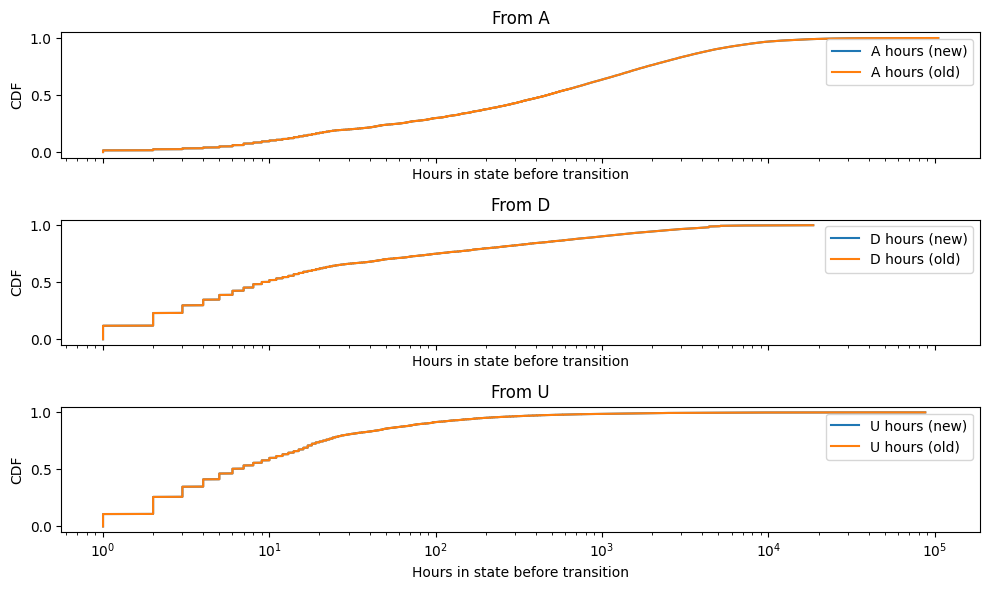

In [20]:
fig, axs = plt.subplots(3,1, figsize=(10, 6), sharex=True)

for i, state in enumerate(['A', 'D', 'U']):
    subset_new = compressed_df.loc[
        (compressed_df['Initial_gen_state'] == state) &
        (compressed_df['Final_gen_state'] != state)
    ]
    subset_old = df_old.loc[
        (df_old['Initial_gen_state'] == state) &
        (df_old['Final_gen_state'] != state)
    ]
    
    h_new = subset_new['hours_in_state'].to_numpy(dtype=float)
    w_new = subset_new['Data_weight'].to_numpy(dtype=int)
    x_new = 10**np.sort(np.repeat(h_new, w_new))
    cdf_new = np.arange(1, len(x_new) + 1) / len(x_new)

    h_old = subset_old['hours_in_state'].to_numpy(dtype=int)
    w_old = subset_old['Data_weight'].to_numpy(dtype=int)
    x_old = np.sort(np.repeat(h_old, w_old))
    cdf_old = np.arange(1, len(x_old) + 1) / len(x_old)

    ax = axs[i]
    ax.plot(x_new, cdf_new, label=f'{state} hours (new)')
    ax.plot(x_old, cdf_old, label=f'{state} hours (old)')
    ax.set_title(f'From {state}')
    ax.set_xlabel('Hours in state before transition')
    ax.set_ylabel('CDF')
    ax.set_xscale('log')
    ax.legend()

plt.tight_layout()
plt.show()

In [18]:

print("Transition counts in new dataset:")
count_dict = defaultdict(dict)
for init in ["A", "D", "U"]:
    for fin in ["A", "D", "U"]:
        count = compressed_df.loc[
            (compressed_df["Initial_gen_state"] == init) &
            (compressed_df["Final_gen_state"] == fin)
        ]["Data_weight"].sum()
        count_dict[init][fin] = count

df_count = pd.DataFrame(count_dict).T
print(df_count)

Transition counts in new dataset:
           A        D        U
A  183503233    10941    83066
D      11053  5084366     3658
U      82863     3801  6866987


In [19]:
print("Share of dataset (%):")
total = df_count.values.sum()
print(df_count/total * 100)

Share of dataset (%):
           A         D         U
A  93.791599  0.005592  0.042456
D   0.005649  2.598705  0.001870
U   0.042353  0.001943  3.509833


In [21]:
print("Frequency per initial state:")
T = df_count.sum(axis=1)
print(df_count.div(T, axis=0)*100)


Frequency per initial state:
           A          D          U
A  99.948797   0.005959   0.045244
D   0.216765  99.711497   0.071738
U   1.191647   0.054662  98.753691
